<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [3]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 170.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 190.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 146.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 156.4 MB/s eta 0:00:00


##### Import Necessary Modules:


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [11]:
# Define the URL of the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path, index_col=0)

# Display the first few rows to ensure it loaded correctly
print(df.head())


                                MainBranch                 Age  \
ResponseId                                                       
1           I am a developer by profession  Under 18 years old   
2           I am a developer by profession     35-44 years old   
3           I am a developer by profession     45-54 years old   
4                    I am learning to code     18-24 years old   
5           I am a developer by profession     18-24 years old   

                     Employment RemoteWork   Check  \
ResponseId                                           
1           Employed, full-time     Remote  Apples   
2           Employed, full-time     Remote  Apples   
3           Employed, full-time     Remote  Apples   
4            Student, full-time        NaN  Apples   
5            Student, full-time        NaN  Apples   

                                             CodingActivities  \
ResponseId                                                      
1                           

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [35]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 1 to 65437
Columns: 113 entries, MainBranch to JobSat
dtypes: float64(13), str(100)
memory usage: 56.4 MB


,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [36]:
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



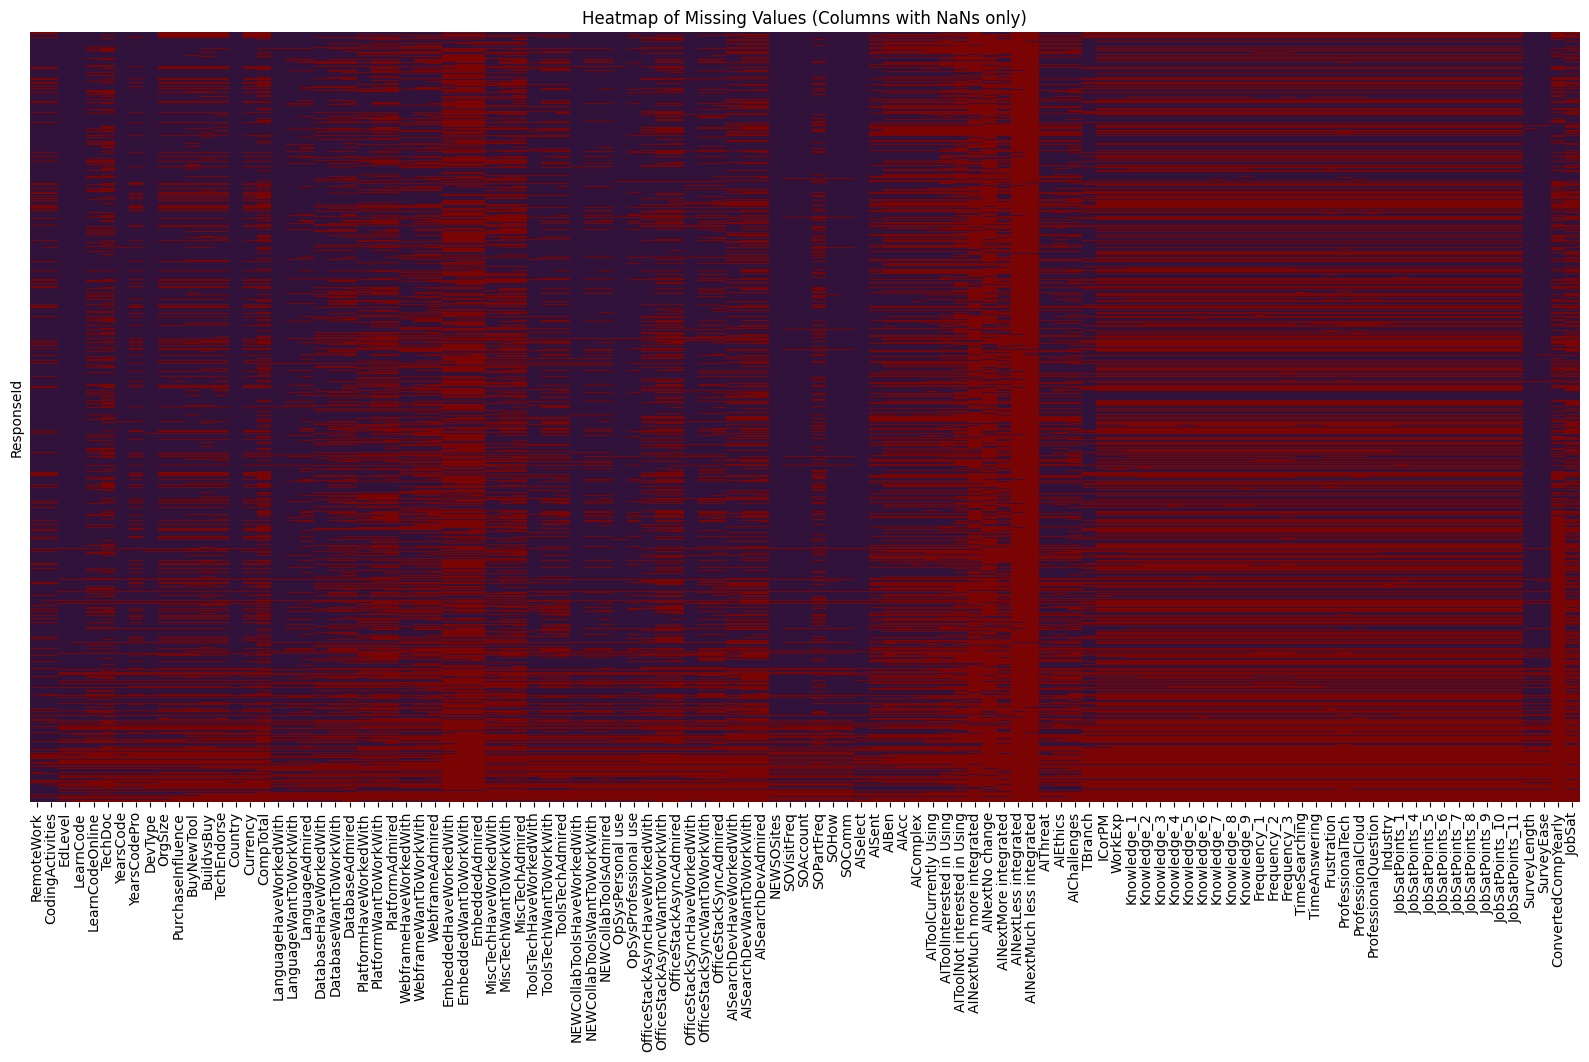

In [37]:
plt.figure(figsize=(20, 10))
sns.heatmap(df_missing.isnull(), 
            yticklabels=False, 
            cbar=False,
            cmap='turbo') 
plt.title('Heatmap of Missing Values')
plt.xticks(rotation=90) 
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [42]:
# added two because the values of Employment being 0 was confusing
print(f"Total missing in Coding Activities: {df['CodingActivities'].isnull().sum()}")
print(f"Total missing in Employment: {df['Employment'].isnull().sum()}")

Total missing in Coding Activities: 10971
Total missing in Employment: 0


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [44]:
# added two as Employment values in task 4 was confusing me
print(f"most frequent value in coding activities: {df['CodingActivities'].mode()[0]}")
print(f"most frequent value in coding activities: {df['Employment'].mode()[0]}")

most frequent value in coding activities: Hobby
most frequent value in coding activities: Employed, full-time


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [60]:
employment_mode = df['Employment'].mode()[0]
df['Employment'] = df['Employment'].fillna(employment_mode) 
print(f"Most frequent value used for Employment: {employment_mode}")
print(f"Missing values remaining in 'Employment': {df['Employment'].isnull().sum()}")

coding_mode = df['CodingActivities'].mode()[0]
df['CodingActivities'] = df['CodingActivities'].fillna(coding_mode)
print(f"Most frequent value used for Coding Activities: {coding_mode}")
print(f"Missing values remaining in 'CodingActivities': {df['CodingActivities'].isnull().sum()}")

Missing values (NaN): 0
Empty strings: 0
Missing values (NaN): 0
Empty strings: 0


### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


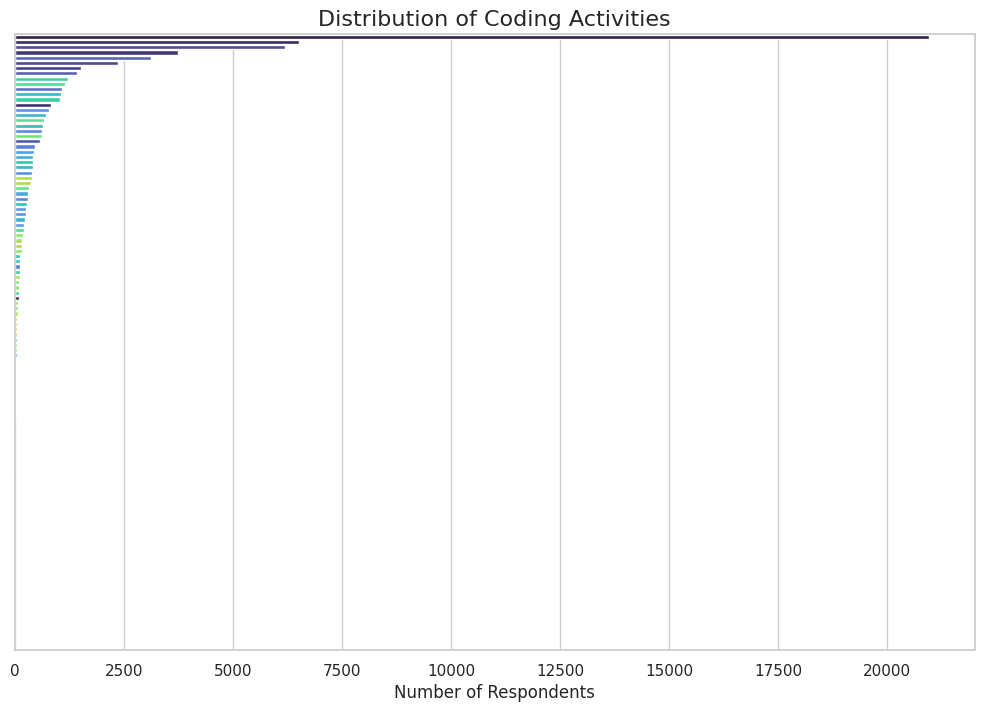

In [65]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))
sns.countplot(
    data=df.dropna(subset=['CodingActivities']), 
    y='CodingActivities', 
    order=df['CodingActivities'].value_counts().index, 
    hue='CodingActivities', 
    palette='turbo',
    legend=False
)
plt.title('Distribution of Coding Activities', fontsize=16)
plt.xlabel('Number of Respondents', fontsize=12)
plt.yticks([]) 
plt.ylabel('') 
plt.subplots_adjust(left=0.1) 
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
